# Load Dataset

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Models
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("/content/drive/MyDrive/project/online_shoppers_intention.csv")
print(df.head())
print("Shape:", df.shape)

   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0         0.0   Feb   

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [ ]:
continuous_vars = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]
# Defined categorical variables for LabelEncoding
categorical_vars = [
    "VisitorType",
    "Weekend",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "Month"
]

target = "Revenue"
df[target] = df[target].map({True: 0, False: 1})
display(df[target].value_counts())

,count
Revenue,
1,10422
0,1908


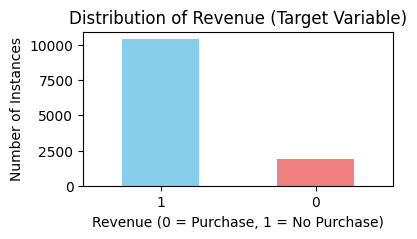

In [ ]:
import matplotlib.pyplot as plt

# Get the value counts of the 'Revenue' column
revenue_counts = df['Revenue'].value_counts()

# Create a bar chart
plt.figure(figsize=(4, 2))
revenue_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Distribution of Revenue (Target Variable)')
plt.xlabel('Revenue (0 = Purchase, 1 = No Purchase)')
plt.ylabel('Number of Instances')
plt.xticks(rotation=0)
plt.show()

# Scaling and Encoding dataset

In [ ]:
# =====================================================
# STEP 5 — LABEL ENCODE CATEGORICAL VARIABLES
# =====================================================
le = LabelEncoder()
for col in categorical_vars:
    df[col] = le.fit_transform(df[col])


# =====================================================
# STEP 6 — STANDARDIZE CONTINUOUS
# =====================================================
scaler = StandardScaler()
df[continuous_vars] = scaler.fit_transform(df[continuous_vars])

Training Data Information

In [ ]:
X = df.drop(columns=[target])
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  float64
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  float64
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  float64
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  int64  
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

Testing Data Information

In [ ]:
y = df[target]
display(y.info())

<class 'pandas.core.series.Series'>
RangeIndex: 12330 entries, 0 to 12329
Series name: Revenue
Non-Null Count  Dtype
--------------  -----
12330 non-null  int64
dtypes: int64(1)
memory usage: 96.5 KB


None

Descriptive Statistics

In [ ]:
display(df.describe())

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,-2.996612e-17,6.281359e-17,-4.610172e-18,-2.535595e-17,4.610172e-17,-8.298309e-17,-6.454241e-17,3.688137e-17,1.060340e-16,-5.532206e-17,5.163990,1.124006,1.357097,2.147364,3.069586,1.718329,0.232603,0.845255
std,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,2.370199,0.911325,1.717277,2.401591,4.025169,0.690759,0.422509,0.361676
min,-6.969930e-01,-4.571914e-01,-3.964779e-01,-2.449305e-01,-7.134884e-01,-6.243475e-01,-4.576830e-01,-8.863706e-01,-3.171778e-01,-3.088214e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-6.969930e-01,-4.571914e-01,-3.964779e-01,-2.449305e-01,-5.560920e-01,-5.281214e-01,-4.576830e-01,-5.923930e-01,-3.171778e-01,-3.088214e-01,5.000000,1.000000,1.000000,0.000000,1.000000,2.000000,0.000000,1.000000
50%,-3.959377e-01,-4.147639e-01,-3.964779e-01,-2.449305e-01,-3.087548e-01,-3.113566e-01,-3.934903e-01,-3.686913e-01,-3.171778e-01,-3.088214e-01,6.000000,1.000000,1.000000,2.000000,1.000000,2.000000,0.000000,1.000000
75%,5.072280e-01,7.035981e-02,-3.964779e-01,-2.449305e-01,1.409492e-01,1.407881e-01,-1.109348e-01,1.425510e-01,-3.171778e-01,-3.088214e-01,7.000000,2.000000,1.000000,3.000000,3.000000,2.000000,0.000000,1.000000
max,7.431499e+00,1.876956e+01,1.849960e+01,1.786868e+01,1.513858e+01,3.280678e+01,3.667189e+00,3.229316e+00,1.916634e+01,4.718598e+00,9.000000,7.000000,12.000000,8.000000,19.000000,2.000000,1.000000,1.000000


Train test split data

In [ ]:

categorical_cols_to_encode = ['Month', 'VisitorType', 'Weekend']

for col in categorical_cols_to_encode:
    if col in df.columns:
        frequency_map = df[col].value_counts(normalize=True).to_dict()
        df[col] = df[col].map(frequency_map)

X = df.drop('Revenue', axis=1)
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("samples Distribution Count for Training\n")
print(y_train.value_counts())
print("\nsamples Distribution Count for Testing\n")
print(y_test.value_counts())

samples Distribution Count for Training

Revenue
1    8338
0    1526
Name: count, dtype: int64

samples Distribution Count for Testing

Revenue
1    2084
0     382
Name: count, dtype: int64


Applying Smote to Train and Test data

In [ ]:
from imblearn.over_sampling import SMOTE
# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Shape of X_train after SMOTE: {X_train_res.shape}")
print(f"Shape of y_train after SMOTE: {y_train_res.shape}")

Shape of X_train after SMOTE: (16676, 17)
Shape of y_train after SMOTE: (16676,)


Defining parameter grids for models

In [ ]:
print('Defining parameter grids for GridSearchCV...')

# Parameter grid for RandomForestClassifier
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# Parameter grid for ExtraTreesClassifier
et_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# Parameter grid for XGBClassifier
xgb_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5,7],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

print('Parameter grids defined.')

Defining parameter grids for GridSearchCV...
Parameter grids defined.


Performing GridSearch on resampled Data

In [ ]:
print('\n Performing Grid Search for Hyperparameter Tuning ')

# GridSearchCV for RandomForestClassifier
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=3, # Number of folds in cross-validation. Reduce for faster execution
    verbose=2,
    n_jobs=-1,
    scoring='roc_auc'
)
print('Fitting RandomForestClassifier GridSearchCV on resampled data...')
rf_grid.fit(X_train_res, y_train_res)
print(f'Best parameters for RandomForest: {rf_grid.best_params_}')

# GridSearchCV for ExtraTreesClassifier
et_grid = GridSearchCV(
    estimator=ExtraTreesClassifier(random_state=42, n_jobs=-1),
    param_grid=et_param_grid,
    cv=3,
    verbose=2,
    n_jobs=-1,
    scoring='roc_auc'
)
print('\nFitting ExtraTreesClassifier GridSearchCV on resampled data...')
et_grid.fit(X_train_res, y_train_res)
print(f'Best parameters for ExtraTrees: {et_grid.best_params_}')

# GridSearchCV for XGBClassifier
xgb_grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    param_grid=xgb_param_grid,
    cv=3,
    verbose=2,
    n_jobs=-1,
    scoring='roc_auc'
)
print('\nFitting XGBClassifier GridSearchCV on resampled data...')
xgb_grid.fit(X_train_res, y_train_res)
print(f'Best parameters for XGBoost: {xgb_grid.best_params_}')

print('\nHyperparameter tuning complete for base models with SMOTE-resampled data.')


 Performing Grid Search for Hyperparameter Tuning 
Fitting RandomForestClassifier GridSearchCV on resampled data...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters for RandomForest: {'bootstrap': False, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Fitting ExtraTreesClassifier GridSearchCV on resampled data...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters for ExtraTrees: {'bootstrap': False, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Fitting XGBClassifier GridSearchCV on resampled data...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters for XGBoost: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.9}

Hyperparameter tuning complete for base models with SMOTE-resampled data.


In [ ]:
print('\n Updating Tri-Ensemble with GridSearchCV tuned models and training...')

def build_tuned_triensemble_gridsearch(rf_best_params, et_best_params, xgb_best_params):
    rf_tuned = RandomForestClassifier(random_state=42, n_jobs=-1, **rf_best_params)
    et_tuned = ExtraTreesClassifier(random_state=42, n_jobs=-1, **et_best_params)
    xgb_tuned = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1, **xgb_best_params)

    meta = LogisticRegression(max_iter=2000)

    model_tuned_grid = StackingClassifier(
        estimators=[
            ("rf", rf_tuned),
            ("et", et_tuned),
            ("xgb", xgb_tuned)
        ],
        final_estimator=meta,
        passthrough=True,
        n_jobs=-1
    )
    return model_tuned_grid

# Build and train the tuned tri-ensemble model using GridSearchCV results
model_tuned_grid = build_tuned_triensemble_gridsearch(
    rf_grid.best_params_,
    et_grid.best_params_,
    xgb_grid.best_params_
)

print('Fitting Tuned Tri-Ensemble Model (GridSearchCV)...')
model_tuned_grid.fit(X_train, y_train)
print('\nTuned Tri-Ensemble model (GridSearchCV) trained successfully.')


 Updating Tri-Ensemble with GridSearchCV tuned models and training...
Fitting Tuned Tri-Ensemble Model (GridSearchCV)...

Tuned Tri-Ensemble model (GridSearchCV) trained successfully.


In [ ]:
print('\n====================================')
print('EVALUATING TUNED TRI-ENSEMBLE MODEL (GridSearchCV)')
print('====================================')

# Predict using the GridSearchCV tuned model
preds_tuned_grid = model_tuned_grid.predict(X_test)

# Calculate overall accuracy for the GridSearchCV tuned model
overall_acc_tuned_grid = accuracy_score(y_test, preds_tuned_grid)
print(f'\nOverall Accuracy (GridSearchCV Tuned Model): {overall_acc_tuned_grid:.4f}')

# Display classification report for the GridSearchCV tuned model
print('\nClassification Report (GridSearchCV Tuned Model):\n', classification_report(y_test, preds_tuned_grid))


EVALUATING TUNED TRI-ENSEMBLE MODEL (GridSearchCV)

Overall Accuracy (GridSearchCV Tuned Model): 0.9023

Classification Report (GridSearchCV Tuned Model):
               precision    recall  f1-score   support

           0       0.76      0.53      0.63       382
           1       0.92      0.97      0.94      2084

    accuracy                           0.90      2466
   macro avg       0.84      0.75      0.79      2466
weighted avg       0.90      0.90      0.89      2466




SHAP Explanations (Alternative Visualizations)
Calculating SHAP values... This may take a few minutes.


  0%|          | 0/50 [00:00<?, ?it/s]


Global Feature Importance (SHAP Bar Plot):


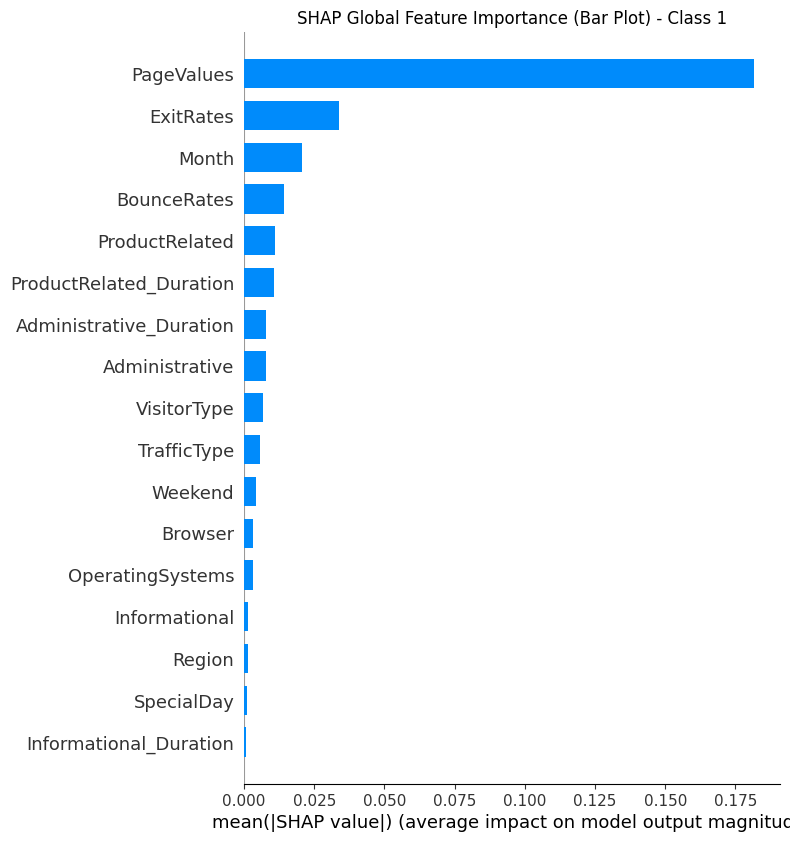


Local Feature Importance (SHAP Waterfall Plot):


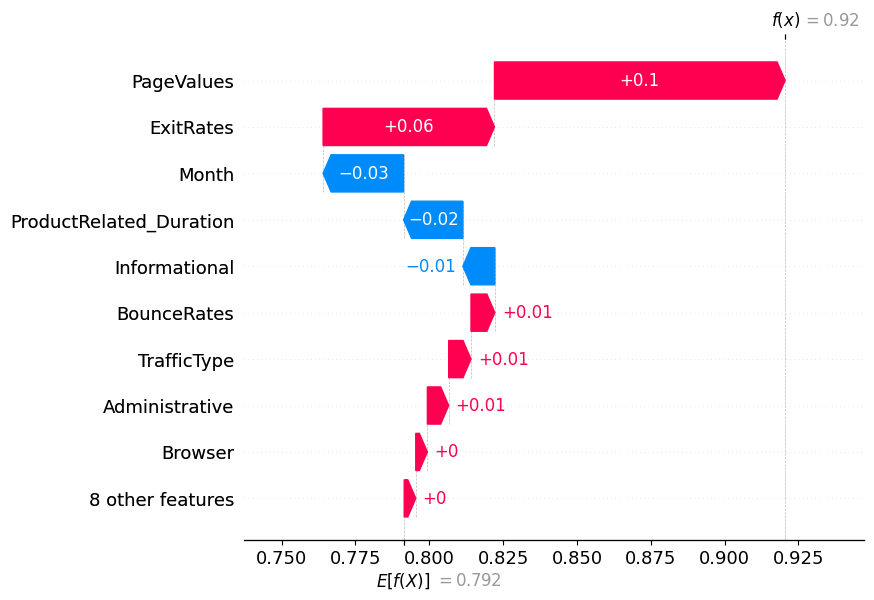


SHAP Decision Plot (First 10 Samples):


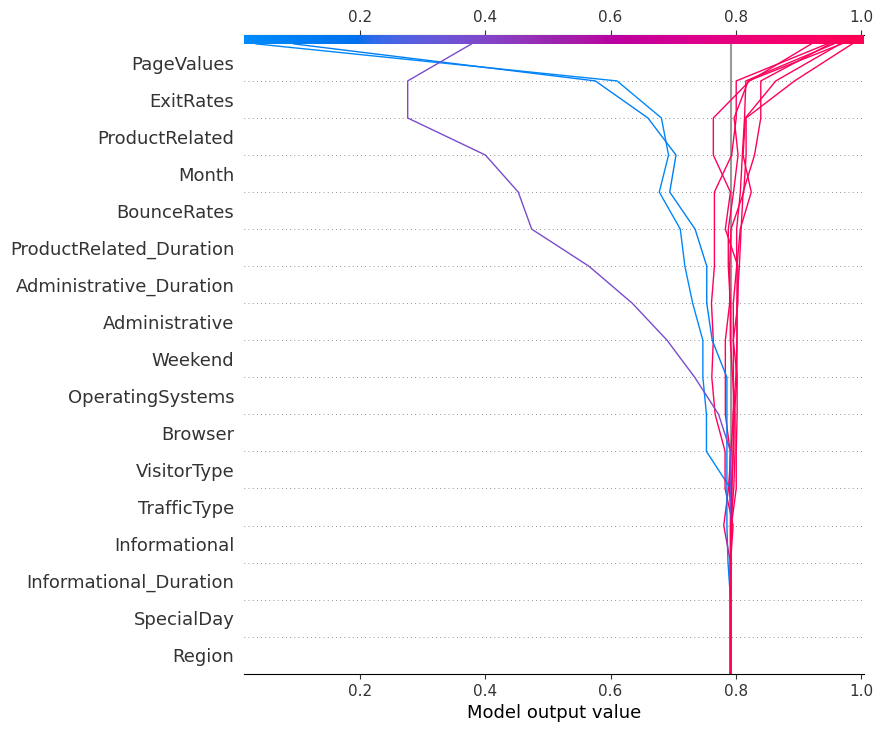

In [ ]:
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

print("\n===================================")
print("SHAP Explanations (Alternative Visualizations)")
print("===================================")

explainer_shap = shap.KernelExplainer(
    model_tuned_grid.predict_proba,
    shap.sample(X_train, 100, random_state=42)
)

X_test_sample_shap = shap.sample(X_test, 50, random_state=42)

print("Calculating SHAP values... This may take a few minutes.")
shap_values = explainer_shap.shap_values(X_test_sample_shap)

# -----------------------------------------
# 1️⃣ Global Feature Importance (BAR PLOT)
# -----------------------------------------
print("\nGlobal Feature Importance (SHAP Bar Plot):")

shap.summary_plot(
    shap_values[:, :, 1],
    X_test_sample_shap,
    plot_type="bar",
    show=False
)

plt.title("SHAP Global Feature Importance (Bar Plot) - Class 1")
plt.show()


# -----------------------------------------
# 2️⃣ Local Explanation (WATERFALL PLOT)
# -----------------------------------------
print("\nLocal Feature Importance (SHAP Waterfall Plot):")

shap.plots._waterfall.waterfall_legacy(
    explainer_shap.expected_value[1],
    shap_values[0, :, 1],
    feature_names=X_test_sample_shap.columns
)


# -----------------------------------------
# 3️⃣ Decision Plot (Multiple Samples)
# -----------------------------------------
print("\nSHAP Decision Plot (First 10 Samples):")

shap.decision_plot(
    explainer_shap.expected_value[1],
    shap_values[:10, :, 1],
    X_test_sample_shap.iloc[:10]
)


🧠 SHAP Explanations
Calculating SHAP values... This may take a few minutes.


  0%|          | 0/50 [00:00<?, ?it/s]


Global Feature Importance (SHAP Summary Plot):


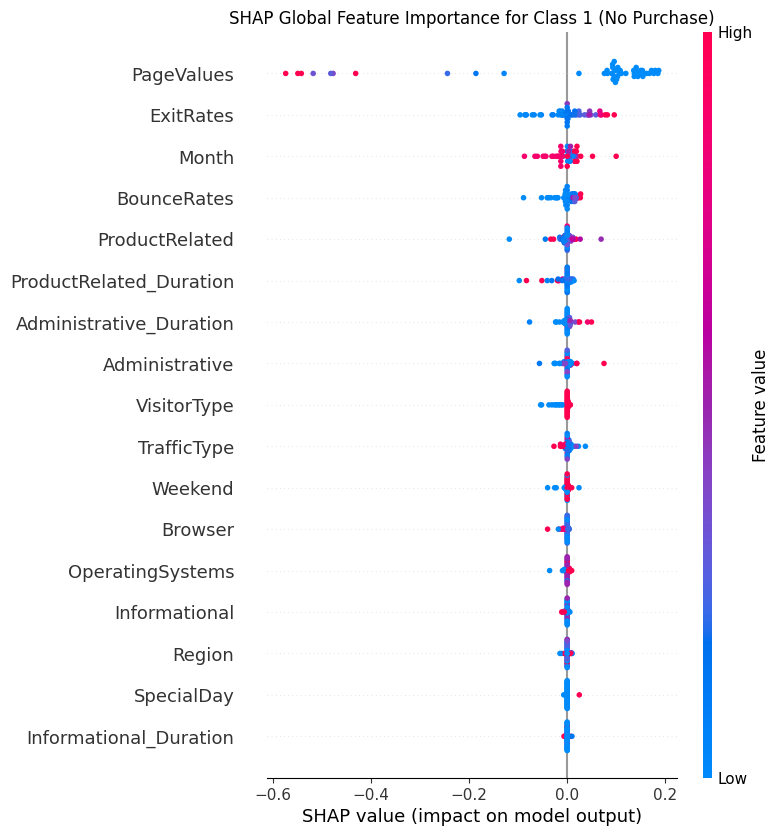


Local Feature Importance (SHAP Force Plot) for an example prediction:


In [ ]:
# print('Installing LIME and SHAP...')
# !pip install lime shap
# print('LIME and SHAP installed. Generating model explanations...')

import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

print("\n===================================")
print("🧠 SHAP Explanations")
print("===================================")

explainer_shap = shap.KernelExplainer(model_tuned_grid.predict_proba, shap.sample(X_train, 100, random_state=42))

# Select a subset of the test data for explanations (e.g., 50 samples)
X_test_sample_shap = shap.sample(X_test, 50, random_state=42)

# Calculate SHAP values
print("Calculating SHAP values... This may take a few minutes.")
shap_values = explainer_shap.shap_values(X_test_sample_shap)

# Visualize global feature importance (Summary Plot - Beeswarm)
print("\nGlobal Feature Importance (SHAP Summary Plot):")
# Corrected: Slice for class 1 across all samples and features
shap.summary_plot(shap_values[:, :, 1], X_test_sample_shap, show=False)
plt.title('SHAP Global Feature Importance for Class 1 (No Purchase)')
plt.show()

# Visualize local feature importance for a single prediction (Force Plot)
# Let's pick the first instance from the sampled test data
print("\nLocal Feature Importance (SHAP Force Plot) for an example prediction:")
# Corrected: Slice for class 1 for the first sample and all features
shap.force_plot(explainer_shap.expected_value[1], shap_values[0, :, 1], X_test_sample_shap.iloc[0,:])


In [ ]:
from lime import lime_tabular
import pandas as pd
def predict_proba_wrapper(X_input):
    X_df = pd.DataFrame(X_input, columns=X_train.columns)
    return model_tuned_grid.predict_proba(X_df)

# Initialize LimeTabularExplainer
explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No Revenue', 'Revenue'],
    mode='classification'
)

print("LimeTabularExplainer initialized.")

# Select instances for explanation from X_test_sample_shap
instance_1_idx = 0
instance_2_idx = 1

instance_1 = X_test_sample_shap.iloc[instance_1_idx]
instance_2 = X_test_sample_shap.iloc[instance_2_idx]

# Get true labels for these instances from y_test using their original index
true_label_1 = y_test.loc[instance_1.name]
true_label_2 = y_test.loc[instance_2.name]


# Generate explanation for the first instance
print(f"\nGenerating LIME explanation for instance {instance_1_idx} (true label: {true_label_1})...")
explanation_1 = explainer.explain_instance(
    data_row=instance_1.values,
    predict_fn=predict_proba_wrapper,
    num_features=10
)

print(f"LIME explanation for instance {instance_1_idx} generated.")

# Generate explanation for the second instance
print(f"\nGenerating LIME explanation for instance {instance_2_idx} (true label: {true_label_2})...")
explanation_2 = explainer.explain_instance(
    data_row=instance_2.values,
    predict_fn=predict_proba_wrapper,
    num_features=10 # Show top 10 features
)

print(f"LIME explanation for instance {instance_2_idx} generated.")

print("\nDisplaying explanation for instance 1:")
explanation_1.show_in_notebook(show_table=True)

print("\nDisplaying explanation for instance 2:")
explanation_2.show_in_notebook(show_table=True)

LimeTabularExplainer initialized.

Generating LIME explanation for instance 0 (true label: 0)...
LIME explanation for instance 0 generated.

Generating LIME explanation for instance 1 (true label: 0)...
LIME explanation for instance 1 generated.

Displaying explanation for instance 1:



Displaying explanation for instance 2:


In [ ]:
from sklearn.metrics import roc_auc_score

print('Initializing and training initial Tri-Ensemble model...')

# 1. Initialize base estimators for the initial tri-ensemble model with default parameters
rf_initial = RandomForestClassifier(random_state=42, n_jobs=-1)
et_initial = ExtraTreesClassifier(random_state=42, n_jobs=-1)
xgb_initial = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)

# Initialize the meta-estimator
meta_initial = LogisticRegression(max_iter=2000)

# 2. Create an instance of StackingClassifier named model_initial
model_initial = StackingClassifier(
    estimators=[
        ("rf", rf_initial),
        ("et", et_initial),
        ("xgb", xgb_initial)
    ],
    final_estimator=meta_initial,
    passthrough=True,
    n_jobs=-1
)

# 3. Train model_initial using the X_train and y_train data
model_initial.fit(X_train, y_train)
print('Initial Tri-Ensemble model trained.')

print('\nPredicting probabilities and calculating ROC AUC scores...')
# 4. Predict the probabilities for the positive class (class 1) for both models
proba_initial = model_initial.predict_proba(X_test)[:, 1]
proba_tuned_grid = model_tuned_grid.predict_proba(X_test)[:, 1]

# 5. Calculate the ROC AUC score for both models
roc_auc_initial = roc_auc_score(y_test, proba_initial)
roc_auc_tuned_grid = roc_auc_score(y_test, proba_tuned_grid)

print(f'ROC AUC for Initial Tri-Ensemble Model: {roc_auc_initial:.4f}')
print(f'ROC AUC for GridSearchCV Tuned Tri-Ensemble Model: {roc_auc_tuned_grid:.4f}')

# Prepare the performance_df if it doesn't exist or add new metrics
if 'performance_df' not in locals() or 'performance_df' not in globals():
    performance_df = pd.DataFrame(index=['Initial Tri-Ensemble', 'GridSearchCV Tuned Tri-Ensemble'])

# 6. Add the calculated ROC AUC scores as a new column named 'ROC_AUC' to the performance_df DataFrame
performance_df.loc['Initial Tri-Ensemble', 'ROC_AUC'] = roc_auc_initial
performance_df.loc['GridSearchCV Tuned Tri-Ensemble', 'ROC_AUC'] = roc_auc_tuned_grid

display(performance_df)

Initializing and training initial Tri-Ensemble model...
Initial Tri-Ensemble model trained.

Predicting probabilities and calculating ROC AUC scores...
ROC AUC for Initial Tri-Ensemble Model: 0.9197
ROC AUC for GridSearchCV Tuned Tri-Ensemble Model: 0.9205


,Accuracy,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,ROC_AUC
Initial Tri-Ensemble,0.901054,0.755556,0.534031,0.625767,0.918944,0.96833,0.942991,0.919736
GridSearchCV Tuned Tri-Ensemble,0.902271,0.764045,0.534031,0.628659,0.919054,0.96977,0.943731,0.920467



Generating bar chart for Classification Report (GridSearchCV Tuned Model)...


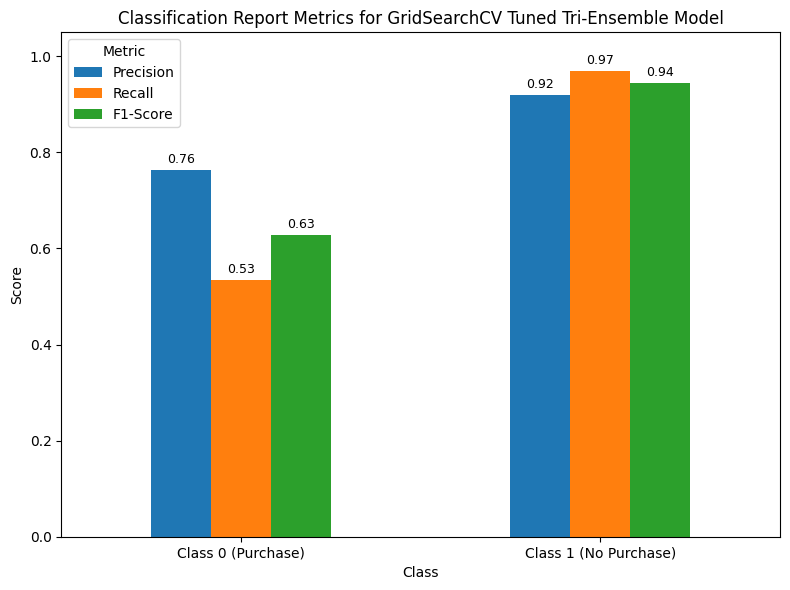


Classification Report bar chart generated.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

print('\nGenerating bar chart for Classification Report (GridSearchCV Tuned Model)...')

# Extract metrics for Class 0 and Class 1 from the report_tuned_grid
class_0_metrics = {
    'Precision': report_tuned_grid['0']['precision'],
    'Recall': report_tuned_grid['0']['recall'],
    'F1-Score': report_tuned_grid['0']['f1-score']
}

class_1_metrics = {
    'Precision': report_tuned_grid['1']['precision'],
    'Recall': report_tuned_grid['1']['recall'],
    'F1-Score': report_tuned_grid['1']['f1-score']
}

# Create a DataFrame for plotting
classification_report_df = pd.DataFrame({
    'Class 0 (Purchase)': class_0_metrics,
    'Class 1 (No Purchase)': class_1_metrics
}).T # Transpose to have classes as rows and metrics as columns

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
classification_report_df.plot(kind='bar', ax=ax, width=0.5)

plt.title('Classification Report Metrics for GridSearchCV Tuned Tri-Ensemble Model')
plt.xlabel('Class')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)

# Annotate bars with their values
for container in ax.containers:
    for i, v in enumerate(container.get_children()):
        ax.annotate(f'{v.get_height():.2f}', xy=(v.get_x() + v.get_width() / 2, v.get_height()),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)

plt.legend(title='Metric')
plt.tight_layout()
plt.show()

print('\nClassification Report bar chart generated.')